In [ ]:
import os
import time
from copy import deepcopy

import matplotlib.pyplot as plt
import torch
from torch import Tensor
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
from barostat_utils import (
    estimate_initial_box_vel_y,
    estimate_initial_box_vel_y_accurate,
    update_box_y_thermodynamic,
)
from graph_utils import prepare_traj
from itpo_weights import DatasetType
from pressure import compute_per_particle_forces, compute_total_stress
from simulator_SA_pos import Model as PositionModel
from training_utils import (
    ModelInputs,
    freeze_normalizer,
)
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    get_correct_edge_attr,
    load_and_split_dataset,
    visualize_nu_disribution,
)


### Load Data

Loading data with max simulation length of 200...


test  data: 100%|██████████| 125/125 [00:04<00:00, 27.67it/s]



Preparing data...


test  data: 100%|██████████| 125/125 [00:04<00:00, 28.61it/s]



Train data: 250 sims.
Val data:   125 sims.
Test data:  125 sims.


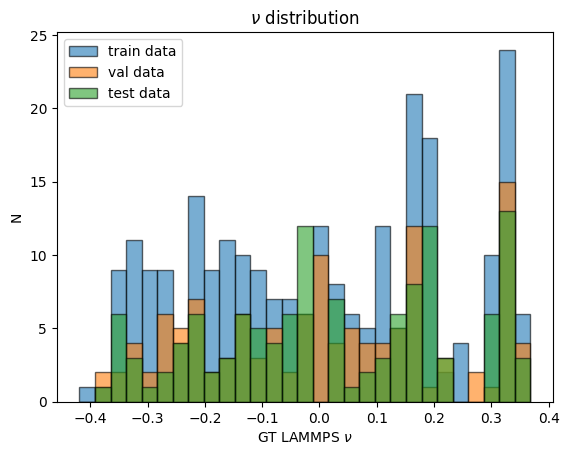

In [ ]:
poisson_buckets = [
    {"max": 0.1, "count": 300},               # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100},   # 0.1 <= P < 0.2
    {"min": 0.2, "count": 100}                # P >= 0.2
]

dataset_type = DatasetType.NodeOptimized

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    registry_path="./data/data_registry.csv",
    # registry_path="./data_reid_with_angles/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}

max_sim_len = 200
print(f"Loading data with max simulation length of {max_sim_len}...")
# stride = 5
# print(f"Loading data with additional stride of {stride}.")
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(train_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(val_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False)[:max_sim_len] for file in tqdm(test_files, desc=f"{key:<5} data")]
        # data[key] = [torch.load(file, weights_only=False)[::stride] for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")

visualize_nu_disribution(data)


### Training GNN positions-based simulator

#### Initialize position-based simulator

In [3]:
history = 0
mp_layers = 2
mlp = 3
hidden_size = 128
device = "cuda"

init_graph = build_velocity_graph_correction(
    input_graphs=[data['train'][0][i].cpu().detach() for i in range(history + 1)],
    total_velocity=False,
    panic_at_positions=False
).to(device)

gnn_simulator = PositionModel(init_graph, hidden_size, mp_layers, mlp, device).to(device)


#### One-step Training loop

Here we train on a portion of training data with high Poisson's ratio, either $\nu > 0.1$ or $\nu > 0.2$.

In [ ]:
model_save_directory = os.path.join("./position_models", f"{dataset_type}", "OST")
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 150
freeze_norm_epoch = 5
train_sims = 100
val_sims = 20
train_limit = 15
accumulation_steps = 10
learning_rate = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(f"Using {len(training_data)} simulations with Poisson's ratio >= {poisson_threshold} for training. ")

# training_data = data['train'][:train_sims]
# print(f"Using {len(training_data)} simulations with full range of Poisson's ratios for training. ")

# Validation data can be full Poisson's ratio range

optimizer = torch.optim.Adam(gnn_simulator.parameters(), lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)

optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    total_velocity_loss = 0
    total_val_loss = 0
    total_val_pos_mse = 0
    train_samples = 0
    val_samples = 0

    gnn_simulator.train()
    for sim in training_data:
        starting_points = [i for i in range(train_limit)]

        for i, idx in enumerate(starting_points):
            indices = [step + idx for step in range(history + 1)]
            target_idx = history + 1 + idx

            input_graphs_raw = [sim[k].detach().cpu() for k in indices]

            # Construct input graph
            input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device)

            # Construct ModelInputs
            model_inputs = ModelInputs(
                input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                input_graphs_raw[-1].to(device),
                sim[target_idx].to(device)
            )

            # Forward and Loss
            model_output = gnn_simulator(input_graph, is_training=True)
            # acc_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)
            velocity_loss = gnn_simulator.velocity_loss(model_output, model_inputs, is_training=True)

            # Backward
            loss_for_backward = velocity_loss / accumulation_steps
            loss_for_backward.backward()

            # Optimization
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            total_velocity_loss += velocity_loss.item()
            train_samples += 1

        optimizer.step()
        optimizer.zero_grad()

    # Validation
    with torch.no_grad():
        gnn_simulator.eval()
        for val_sim in data['val'][:val_sims]:

            starting_points = [i for i in range(train_limit)]

            for idx in starting_points:
                indices = [step + idx for step in range(history + 1)]
                target_idx = history + 1 + idx

                input_graphs_raw = [val_sim[k].detach().cpu() for k in indices]

                input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device) 

                val_inputs = ModelInputs(
                    input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                    input_graphs_raw[-1].to(device),
                    val_sim[target_idx].to(device),
                )

                # Forward and Loss
                model_output = gnn_simulator(input_graph, is_training=False)
                # val_loss = huber_loss(gnn_simulator, model_output, val_inputs, is_training=False)
                val_loss = gnn_simulator.velocity_loss(model_output, val_inputs, is_training=False)

                # Update to next state and check position MSE
                pred_graph = gnn_simulator.update(val_inputs, model_output)
                pos_mse = torch.nn.functional.mse_loss(pred_graph.pos, val_sim[target_idx].to(device).pos)

                total_val_loss += val_loss.item()
                total_val_pos_mse += pos_mse.item()
                val_samples += 1

    lr_scheduler.step()

    # Statistics
    avg_train_loss = total_velocity_loss / train_samples
    avg_val_loss = total_val_loss / val_samples
    avg_val_pos_mse = total_val_pos_mse / val_samples

    # Save model
    if epoch % 1 == 0:
        gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))

    t_stop = time.perf_counter()
    print(
        f"Epoch {epoch + 1:>3} | "
        f"Train Loss: {avg_train_loss:.3e} | "
        f"Val Loss: {avg_val_loss:.3e} | "
        f"Val Pos MSE: {avg_val_pos_mse:.3e} | "
        f"Time: {t_stop - t_start:.2f} s"
    )

gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"model_h{history}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))


#### Multi-step training loop

In [6]:
torch.set_float32_matmul_precision('high')

In [7]:
model_save_directory = f"./position_models/{dataset_type}/MST"
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 150
train_sims = 100
train_limit: int = 15
max_rollout_steps: int = 10
fresh: bool = True
freeze_norm_epoch: int = 5
learning_rate: float = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(f"Using {len(training_data)} simulations with Poisson's ratio >= {poisson_threshold} for training. ")

# training_data = data['train'][:train_sims]
# print(f"Using {len(training_data)} simulations with full range of Poisson's ratios for training. ")

if dataset_type is DatasetType.NodeOptimized:
    barostat_config = barostat_parameters.node_optimizated 
elif dataset_type is DatasetType.StiffOptimized:
    barostat_config = barostat_parameters.stiff_optimized
elif dataset_type is DatasetType.StiffAngles:
    barostat_config = barostat_parameters.stiff_angles
elif dataset_type is DatasetType.Noisy:
    barostat_config = barostat_parameters.noisy

if barostat_config["default_skip"] is None:
    print("Dump freqiency is computed dynamically.")

gnn_simulator.train()
params = filter(lambda p: p.requires_grad, gnn_simulator.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)

optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if fresh:
        if epoch < 10:
            rollout_steps = 1
        elif epoch >= 10 and epoch < 20:
            rollout_steps = 2
        elif epoch >= 20 and epoch < 30:
            rollout_steps = 3
        elif epoch >= 30 and epoch < 40:
            rollout_steps = 5
        elif epoch >= 40 and epoch < 50:
            rollout_steps = 8
        else:
            rollout_steps = max_rollout_steps

    # Trackers
    total_velocity_loss = 0
    train_samples = 0

    # Freeze normalizers
    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    for sim in training_data:
        # Get equilibrium bond lengths
        r0 = sim[0].edge_attr[:, -2]
        
        starting_points = [i for i in range(train_limit)]
        if barostat_config["default_skip"] is not None:
            dump_period = barostat_config["default_skip"]
        else:
            sim_strain = (sim[1].box.x - sim[-1].box.x) / sim[0].box.x
            assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
            dump_period = int(assumed_rollout_length / len(sim)) + 1

        for start_idx in starting_points:
            optimizer.zero_grad()

            indices = [step + start_idx for step in range(history + 1)]
            current_window_graphs = [sim[k].detach().to(device) for k in indices]

            # Calculate box_delta_x (constant strain rate assumption)
            if start_idx >= 1:
                b0 = sim[start_idx - 1].box_tensor[0]
                b1 = sim[start_idx].box_tensor[0]
            else:
                # If at step 0, calculate forward difference
                b0 = sim[0].box_tensor[0]
                b1 = sim[1].box_tensor[0]
            box_delta_x = b1 - b0

            # 2. Calculate current_box_vel_y from available ground truth history
            if start_idx >= 2:
                current_box_vel_y = estimate_initial_box_vel_y_accurate(
                    sim[start_idx - 3].to(device),
                    sim[start_idx - 2].to(device),
                    sim[start_idx - 1].to(device),
                    dump_period * barostat_config["dt"],
                )
            elif start_idx == 1:
                current_box_vel_y = estimate_initial_box_vel_y(
                    sim[start_idx - 1].to(device),
                    sim[start_idx].to(device),
                    dump_period * barostat_config["dt"],
                )
            else:
                # start_idx == 0: No history available, initialize to zero
                current_box_vel_y = torch.tensor(0.0, device=device, dtype=torch.float32)

            # Initialize prev_graph for the first rollout step
            if start_idx == 0:
                prev_graph = current_window_graphs[0]
            else:
                prev_graph = sim[start_idx - 1].detach().to(device)

            rollout_loss = 0
            for step in range(rollout_steps):
                target_idx = history + 1 + start_idx + step
                target_graph = sim[target_idx].to(device)

                input_graph = build_velocity_graph_correction(current_window_graphs).to(device)

                cur_graph = current_window_graphs[-1]

                model_inputs = ModelInputs(
                    prev_graph,
                    cur_graph,
                    target_graph,
                )

                model_output = gnn_simulator(input_graph, is_training=True)
                pred_graph_next = gnn_simulator.update(model_inputs, model_output)

                # step_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)
                step_loss = gnn_simulator.velocity_loss(model_output, model_inputs, is_training=True)
                rollout_loss += step_loss

                dt = barostat_config["dt"]  # lammps dt
                W_y = barostat_config["C_coupling"] * pred_graph_next.num_nodes * ((dump_period * dt) ** 2)
                damping = barostat_config["damping"] * pred_graph_next.num_nodes * (dump_period * dt)

                new_lx = pred_graph_next.box_tensor[0] + box_delta_x
                new_ly, new_vel_y = update_box_y_thermodynamic(
                    positions=pred_graph_next.pos,
                    edge_index=model_inputs.cur_graph.edge_index,
                    edge_attr=model_inputs.cur_graph.edge_attr,
                    current_box=model_inputs.cur_graph.box_tensor,
                    r0=r0.to(pred_graph_next.pos.device),
                    box_vel_y=current_box_vel_y,  # Use ESTIMATED velocity
                    W_y=W_y,
                    damping=damping,
                    stride_dt=dump_period * dt,
                    target_pressure=barostat_config["target_pressure"],
                    temperature=barostat_config["temperature"],
                )
                new_box_tensor = torch.stack([new_lx, new_ly])
                current_box_vel_y = new_vel_y

                # Add new box and update edge_attr
                pred_graph_next.box_tensor = new_box_tensor
                pred_graph_next.edge_attr = get_correct_edge_attr(
                    pred_graph_next,
                    recompute_stiff=False,
                    panic_at_nontensor_box=True,
                )
                pred_graph_next.forces = compute_per_particle_forces(pred_graph_next, r0=r0.to(pred_graph_next.pos.device))

                pred_graph_next_detached = pred_graph_next.detach()

                prev_graph = cur_graph

                # Update window: shift left, append new prediction
                current_window_graphs.pop(0)
                current_window_graphs.append(pred_graph_next_detached)

            final_loss = rollout_loss / rollout_steps
            final_loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
            optimizer.step()

            total_velocity_loss += final_loss.item()
            train_samples += 1

    gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))

    total_velocity_loss /= train_samples
    lr_scheduler.step()
    t_stop = time.perf_counter()
    print(f"Epoch {epoch:<3} | steps: {rollout_steps:<2} | loss: {total_velocity_loss:.4e} | {t_stop - t_start:.2f} s.")

gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"model_h{history}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))


Using 99 simulations with Poisson's ratio >= 0.1 for training. 
Epoch 0   | steps: 1  | loss: 5.7425e-02 | 12.46 s.
Epoch 1   | steps: 1  | loss: 5.7717e-02 | 5.80 s.
Epoch 2   | steps: 1  | loss: 6.0550e-02 | 5.63 s.
Epoch 3   | steps: 1  | loss: 6.0490e-02 | 5.66 s.
Epoch 4   | steps: 1  | loss: 5.9499e-02 | 5.60 s.
Epoch 5   | steps: 1  | loss: 5.7441e-02 | 5.49 s.
Epoch 6   | steps: 1  | loss: 5.9392e-02 | 5.51 s.
Epoch 7   | steps: 1  | loss: 5.7389e-02 | 5.62 s.
Epoch 8   | steps: 1  | loss: 5.7280e-02 | 5.75 s.
Epoch 9   | steps: 1  | loss: 5.7901e-02 | 5.77 s.
Epoch 10  | steps: 2  | loss: 1.4601e-01 | 9.74 s.
Epoch 11  | steps: 2  | loss: 1.5167e-01 | 9.48 s.
Epoch 12  | steps: 2  | loss: 1.5153e-01 | 9.84 s.
Epoch 13  | steps: 2  | loss: 1.4840e-01 | 9.65 s.
Epoch 14  | steps: 2  | loss: 1.5248e-01 | 9.66 s.
Epoch 15  | steps: 2  | loss: 1.5035e-01 | 9.56 s.
Epoch 16  | steps: 2  | loss: 1.4926e-01 | 9.54 s.
Epoch 17  | steps: 2  | loss: 1.4873e-01 | 9.48 s.
Epoch 18  | steps

KeyboardInterrupt: 

### Test the model

In [11]:
history = 0
mp_layers = 2
mlp = 3
hidden_size = 128
device = "cuda"

init_graph = build_velocity_graph_correction(
    input_graphs=[data['train'][0][i].cpu().detach() for i in range(history + 1)],
    total_velocity=False,
    panic_at_positions=False
).to(device)

models = {}
for epoch in range(0, 105, 10):
    gnn_simulator = PositionModel(init_graph, hidden_size, mp_layers, mlp, device).to(device)
    gnn_simulator.load_checkpoint(f"position_models/node_optimized/MST/checkpoint_epoch_{epoch}.pt")
    gnn_simulator = freeze_normalizer(gnn_simulator)
    gnn_simulator.eval()
    models[f"Epoch {epoch}"] = gnn_simulator

Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_0.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_10.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_20.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_30.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_40.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_50.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_60.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MST/checkpoint_epoch_70.pt
Successfully loaded and migrated LEGACY checkpoint from position_models/node_optimized/MS

In [ ]:
def get_position_rollout(
    input_graph: Data,
    gnn_simulator: PositionModel,
    num_steps: int,
    box_delta_x: Tensor,
    barostat_config: dict,
    device: str = "cuda"
) -> list[Data]:

    # Extract barostat-related parameters
    num_particles = input_graph.x.shape[0]
    r0 = input_graph.edge_attr[:, -2]
    C_coupling = barostat_config["C_coupling"]
    damping_coeff = barostat_config["damping"]
    target_pressure = barostat_config["target_pressure"]
    temperature = barostat_config["temperature"]
    dt = barostat_config["dt"]
    default_skip = barostat_config["default_skip"]
    stride_dt = default_skip * dt
    W_y = C_coupling * num_particles * (stride_dt**2)
    damping = damping_coeff * num_particles * stride_dt

    # Initialize the rollout
    rollout = [input_graph, ]

    # Construct the input graph (actually does nothing)
    local_input_graph = build_velocity_graph_correction([input_graph, ]).to(device)

    # Construct ModelInputs
    inps = ModelInputs(input_graph.to(device), input_graph.to(device), None)

    # Predict velocity and update
    model_output = gnn_simulator(local_input_graph, is_training=False)
    predicted_graph = gnn_simulator.update(inps, model_output)

    # Update the box
    new_box_tensor = predicted_graph.box_tensor.clone()
    new_box_tensor[0] = new_box_tensor[0] + box_delta_x
    new_ly, new_vel_y = update_box_y_thermodynamic(
        positions=predicted_graph.pos,
        edge_index=inps.cur_graph.edge_index,
        edge_attr=inps.cur_graph.edge_attr,
        current_box=inps.cur_graph.box_tensor,
        r0=r0.to(predicted_graph.pos.device),
        box_vel_y=torch.tensor(0.0, device=device),
        W_y=W_y,
        damping=damping,
        stride_dt=stride_dt,
        target_pressure=target_pressure,
        temperature=temperature,
    )
    new_box_tensor[1] = new_ly
    current_box_vel_y = new_vel_y

    # Update the box to graph
    predicted_graph.box_tensor = new_box_tensor

    predicted_graph.edge_attr = get_correct_edge_attr(predicted_graph, recompute_stiff=False, panic_at_nontensor_box=True)
    predicted_graph.forces = compute_per_particle_forces(predicted_graph, r0=r0.to(predicted_graph.x.device))
    rollout.append(predicted_graph.cpu().detach())

    for _ in range(num_steps):

        # Create a new input graph
        local_input_graph = build_velocity_graph_correction([rollout[-1], ]).to(device)

        # Create new model inputs
        inps = ModelInputs(
            rollout[-2].to(device),
            rollout[-1].to(device),
            None
        )

        # Predict velocity and update
        model_output = gnn_simulator(local_input_graph, is_training=False)
        predicted_graph = gnn_simulator.update(inps, model_output)

        # Update the box
        new_box_tensor = predicted_graph.box_tensor.clone()
        new_box_tensor[0] = new_box_tensor[0] + box_delta_x
        new_ly, new_vel_y = update_box_y_thermodynamic(
            positions=predicted_graph.pos,
            edge_index=inps.cur_graph.edge_index,
            edge_attr=inps.cur_graph.edge_attr,
            current_box=inps.cur_graph.box_tensor,
            r0=r0.to(predicted_graph.pos.device),
            box_vel_y=current_box_vel_y,
            W_y=W_y,
            damping=damping,
            stride_dt=stride_dt,
            target_pressure=target_pressure,
            temperature=temperature,
        )
        new_box_tensor[1] = new_ly
        current_box_vel_y = new_vel_y

        # Update the box to graph
        predicted_graph.box_tensor = new_box_tensor

        predicted_graph.edge_attr = get_correct_edge_attr(predicted_graph, recompute_stiff=False, panic_at_nontensor_box=True)
        predicted_graph.forces = compute_per_particle_forces(predicted_graph, r0=r0.to(predicted_graph.x.device))
        rollout.append(predicted_graph.cpu().detach())

    return rollout

In [ ]:
factors = [(sim[4].box_tensor[0] - sim[3].box_tensor[0]).item() for sim in data["test"]]
mean_factor = sum(factors)/len(factors)

num_steps = 1
model_results = {}

if dataset_type is DatasetType.NodeOptimized:
    barostat_config = barostat_parameters.node_optimizated
elif dataset_type is DatasetType.StiffOptimized:
    barostat_config = barostat_parameters.stiff_optimized
elif dataset_type is DatasetType.StiffAngles:
    barostat_config = barostat_parameters.stiff_angles
elif dataset_type is DatasetType.Noisy:
    barostat_config = barostat_parameters.noisy

name_len = max([len(str(n)) for n in models])+1 

for model_name, model in models.items():
    model.eval()

    target_idx = num_steps + 1
    results = {
        "gt_box_velocity": [],
        "pred_box_velocity": [],
        "final_mse": [],
        "mse": [],
        "est_p": [],
        "pred_p": [],
        "gt_est_p": [],
        "gt_p": [],
        "gt_box": [],
        "pred_box": [],
        "gt_forces": [],
        "pred_forces": [],
        "gt_pressure": [],
        "pred_pressure": [],
    }

    with torch.no_grad():
        for val_sim in tqdm(data['test'], desc=f"Model {model_name:<{name_len}}"):

            # This block computes dumping period (N MD steps in 1 dump step)        
            sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
            assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
            dump_period = int(assumed_rollout_length / len(val_sim)) + 1

            barostat_config_current = deepcopy(barostat_config)
            barostat_config_current["default_skip"] = dump_period

            input_graphs = [g.cpu().detach() for g in val_sim[: history + 1]]

            rollout = get_position_rollout(
                input_graph=input_graphs[0],
                gnn_simulator=model,
                num_steps=num_steps,
                box_delta_x=mean_factor,
                barostat_config=barostat_config_current,
                device=device
            )

            # Compare Predicted Position vs Ground Truth Position
            pos_mse = torch.nn.functional.mse_loss(rollout[-1].pos.cpu(), val_sim[target_idx].to(device).pos.cpu()).item()
            results["final_mse"].append(pos_mse)
            pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].to(device).pos.cpu()).item() for i in range(len(rollout))]
            results["mse"].append(pos_mse)
            
            pred_p = calc_p_ratio_box_tensor(rollout).item()
            results["pred_p"].append(pred_p)
            gt_p = calc_p_ratio_box_tensor(val_sim[:target_idx]).item()
            results["gt_p"].append(gt_p)

            pred_box = [g.box_tensor.cpu() for g in rollout]
            results["pred_box"].append(pred_box)
            gt_box = [g.box_tensor.cpu() for g in val_sim[: len(rollout)]]
            results["gt_box"].append(gt_box)

            r0 = val_sim[0].edge_attr[:, -2]
            gt_pressure = torch.stack([compute_total_stress(g, r0=r0.to(g.x.device), temperature=1e-7).cpu() for g in val_sim[:len(rollout)]], dim=0)
            results['gt_pressure'].append(gt_pressure)
            pred_pressure = torch.stack([compute_total_stress(g, r0=r0.to(g.x.device), temperature=1e-7).cpu() for g in rollout], dim=0)
            results["pred_pressure"].append(pred_pressure)

    model_results[model_name] = results

Model Epoch 0   :   0%|          | 0/125 [00:00<?, ?it/s]

Model Epoch 100 : 100%|██████████| 125/125 [00:00<00:00, 209.89it/s]


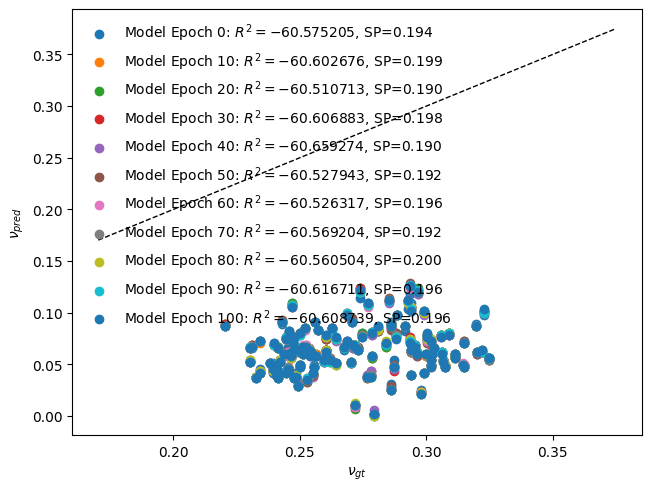

In [ ]:
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

fig, ax = plt.subplots(1, 1, layout="constrained")

line = (min(results["gt_p"]) - 0.05, max(results["gt_p"]) + 0.05)
ax.plot(line, line, color="black", linewidth=1, linestyle='--')

for model_name, results in model_results.items():

    r2 = r2_score(results['gt_p'], results['pred_p'])
    res = spearmanr(results["gt_p"], results["pred_p"])
    sp = res.statistic
    
    label_text = f"Model {model_name}: $R^2={r2:.6f}$, SP={sp:.3f}"
    ax.scatter(results["gt_p"], results["pred_p"], label=label_text)
    
ax.legend(frameon=False, loc='best')
ax.set_xlabel(r"$\nu_{gt}$")
ax.set_ylabel(r"$\nu_{pred}$")

plt.show()
